<a href="https://colab.research.google.com/github/lakkshanarams-maker/aiml-colab/blob/main/finalproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
df = pd.read_csv("heart.csv")

In [ ]:
df = df.drop_duplicates()

In [ ]:
target = "target" if "target" in df.columns else "output"

In [ ]:
X = df.drop(target, axis=1)
y = df[target]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=6,
    min_samples_leaf=2,
    random_state=42
)

In [ ]:
svm = SVC(
    C=1.2,
    kernel='rbf',
    gamma='scale',
    probability=True   # REQUIRED for soft voting
)

In [ ]:
xgb = XGBClassifier(
    n_estimators=120,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    eval_metric='logloss',
    random_state=42
)

In [ ]:
ensemble = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('svm', svm),
        ('xgb', xgb)
    ],
    voting='soft'
)

In [ ]:
ensemble.fit(X_train, y_train)

VotingClassifier(estimators=[('rf',
                              RandomForestClassifier(max_depth=6,
                                                     min_samples_leaf=2,
                                                     n_estimators=150,
                                                     random_state=42)),
                             ('svm', SVC(C=1.2, probability=True)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.85, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=...
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.05, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=3,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=120, n_jobs=None,
                                            num_parallel_tree=None, ...))],
                 voting='soft')

In [ ]:
train_pred = ensemble.predict(X_train)
test_pred = ensemble.predict(X_test)

In [ ]:
train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

In [ ]:
cv_scores = cross_val_score(ensemble, X_train, y_train, cv=5)

In [ ]:
print("\n===================================")
print("ENSEMBLE MODEL (RF + SVM + XGB)")
print("===================================")
print("Train Accuracy:", round(train_acc, 4))
print("Test Accuracy:", round(test_acc, 4))
print("CV Mean Accuracy:", round(cv_scores.mean(), 4))
print("\nClassification Report:\n", classification_report(y_test, test_pred))


ENSEMBLE MODEL (RF + SVM + XGB)
Train Accuracy: 0.9585
Test Accuracy: 0.8197
CV Mean Accuracy: 0.8259

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.68      0.78        28
           1       0.78      0.94      0.85        33

    accuracy                           0.82        61
   macro avg       0.84      0.81      0.81        61
weighted avg       0.83      0.82      0.82        61



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [ ]:
cm = confusion_matrix(y_test, test_pred)

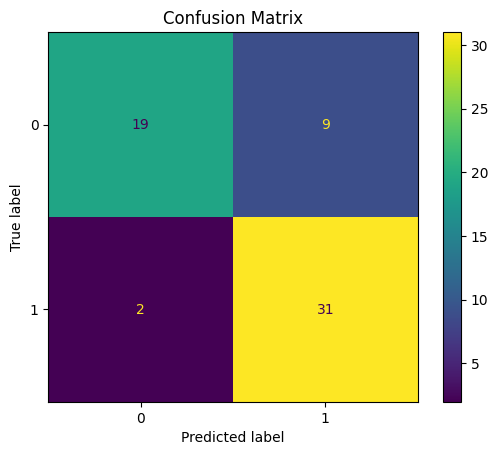

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc
probs = ensemble.predict_proba(X_test)[:, 1]

In [ ]:
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

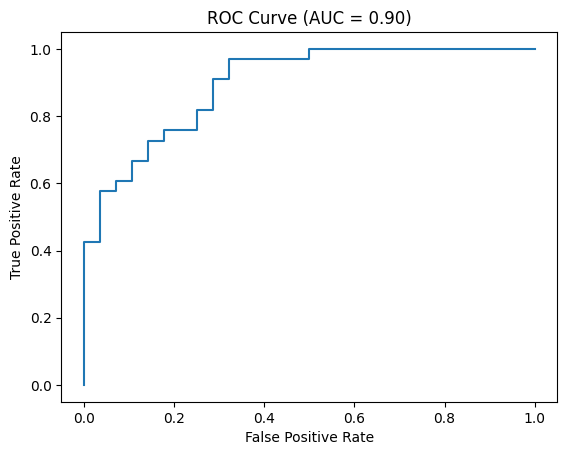

In [ ]:
plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (AUC = %0.2f)" % roc_auc)
plt.show()

In [ ]:
models = ['Train Accuracy', 'Test Accuracy', 'CV Score']
values = [train_acc, test_acc, cv_scores.mean()]

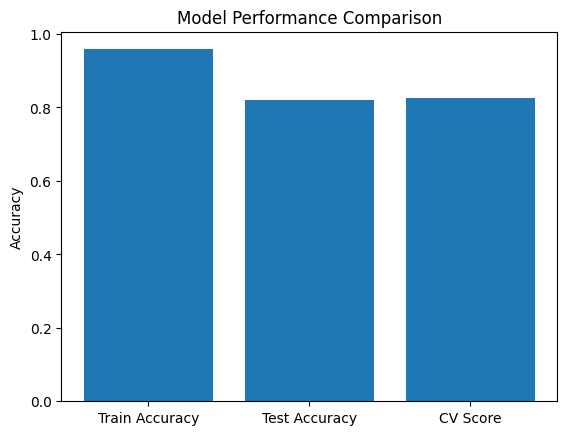

In [ ]:
plt.figure()
plt.bar(models, values)
plt.title("Model Performance Comparison")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score